# Part 2: a careful logistic-regression experiment

An embedding is a list of numbers that represents one query. In this section, we will use those numbers to study a small logistic-regression router. The router predicts whether a query is `relevant` and should reach the nursing team, or `irrelevant` and can be withheld.

A fold is a group of rows held out for checking. An outer fold is held out for the final development check for that round. An inner fold is a smaller held-out group used inside the remaining outer-training rows to choose settings. The experiment uses five outer folds and three inner folds. The complex cross-validation code lives in `src/experiment.py`; this notebook is for reading the saved evidence in a beginner-friendly way.

Precision answers: of the queries we referred, how many were actually relevant? Recall answers: of the actually relevant queries, how many did we catch? A ROC curve has false-positive rate on the horizontal axis and true-positive rate, which is recall, on the vertical axis. ROC AUC is the area under that curve: 0.5 is random ranking and 1.0 is perfect ranking.

The logistic-regression setting `C` controls the constraint on the model. A small `C` means a stronger constraint and a simpler fit; a large `C` means a weaker constraint and a more flexible fit.
The test set has no labels. We can create test predictions, but we cannot calculate test accuracy or claim that the test predictions are correct.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PART2_DIR = Path.cwd()
if PART2_DIR.name.lower() != 'part2':
    PART2_DIR = Path(__file__).resolve().parent if '__file__' in globals() else PART2_DIR / 'version 1' / 'part2'
PROJECT_ROOT = PART2_DIR.parents[1]
if str(PART2_DIR) not in sys.path:
    sys.path.insert(0, str(PART2_DIR))

from src.experiment import run_experiment

# The core worker owns training and writes the machine-readable evidence.
summary = run_experiment(PART2_DIR)
print('Experiment finished. The notebook will now read its saved outputs.')
print(json.dumps(summary, indent=2, default=str)[:4000])

Experiment finished. The notebook will now read its saved outputs.
{
  "stage": "version_1_part2_logistic_regression",
  "cache_hit": true,
  "source_fingerprint": "a84676b586107bb8baf621a013f2e9ce1f5fc0e5762d5b30594772ba6a03ea43",
  "test_metadata_fingerprint": "5f47022efe247427d0f49eb7fde9b927a376243ebbd2a4e8ed55811c92482f11",
  "config_fingerprint": "5939bec9426086fe9cf58339dbe39c80b7425142ef71c8f7ce3d58fb69b0aa3c",
  "cache_fingerprint": "daada54f1ac81665bfe4ebb113a37ed838f0b4e7639d2e37851c53d6bf2528d6",
  "selection": {
    "outer_fold_choices": [
      {
        "outer_fold": 0,
        "outer_train_rows": 722,
        "outer_test_rows": 181,
        "selected_embedding": "b",
        "selected_C": 10.0,
        "selected_class_weight": "None",
        "selected_mean_inner_average_precision": 0.964353363851498,
        "brier_raw": 0.08919525496125812,
        "brier_sigmoid": 0.09006266769818189,
        "probability_method": "raw",
        "threshold_default_0_5": 0.5,
        

## 1. Load the saved evidence

Here, we will load the tables produced by the experiment. Keeping the tables in CSV and the run description in JSON makes the result easy to inspect without opening the notebook. The selected model and threshold will come from the saved summary; this notebook will not make a second selection.

In [2]:
OUTPUT_DIR = PART2_DIR / 'outputs'
CHART_DIR = PART2_DIR / 'charts'
CHART_DIR.mkdir(parents=True, exist_ok=True)
summary_path = OUTPUT_DIR / 'summary.json'
if summary_path.exists():
    saved_summary = json.loads(summary_path.read_text(encoding='utf-8'))
else:
    saved_summary = summary

def read_output(name):
    path = OUTPUT_DIR / name
    if not path.exists():
        raise FileNotFoundError(f'Missing expected core output: {path}')
    return pd.read_csv(path)

metrics = read_output('metrics.csv')
outer_predictions = read_output('outer_predictions.csv')
fold_choices = read_output('fold_choices.csv')
splits = read_output('splits.csv')
candidate_results = read_output('candidate_results.csv')
threshold_sweep = read_output('threshold_sweep.csv')
test_predictions = read_output('test_predictions.csv')

def as_binary(values):
    text = pd.Series(values).astype(str).str.lower()
    return text.isin(['relevant', '1', 'true', 'positive', 'yes']).astype(int).to_numpy()

required_columns = {
    'metrics.csv': {'system', 'embedding', 'policy', 'evaluation', 'n', 'accuracy', 'macro_f1', 'precision', 'recall', 'specificity', 'tp', 'tn', 'fp', 'fn', 'medical_fn', 'medical_n', 'medical_recall', 'referral_fraction', 'roc_auc', 'average_precision', 'score_available', 'note'},
    'outer_predictions.csv': {'row_index', 'query_id', 'outer_fold', 'group_id', 'truth', 'true_label', 'intent', 'selected_embedding', 'selected_C', 'selected_class_weight', 'probability_method', 'p_raw', 'p_chosen', 'threshold_default_0_5', 'threshold_balanced_macro_f1', 'threshold_recall_first', 'label_default_0_5', 'label_balanced_macro_f1', 'label_recall_first', 'llm_predicted_label'},
    'fold_choices.csv': {'outer_fold', 'outer_train_rows', 'outer_test_rows', 'selected_embedding', 'selected_C', 'selected_class_weight', 'selected_mean_inner_average_precision', 'brier_raw', 'brier_sigmoid', 'probability_method', 'threshold_default_0_5', 'threshold_balanced_macro_f1', 'threshold_recall_first', 'recall_first_feasible', 'outer_holdout_excluded_selection'},
    'splits.csv': {'split_level', 'outer_fold', 'role', 'row_index', 'query_id', 'group_id', 'truth', 'label', 'intent'},
    'candidate_results.csv': {'selection_scope', 'outer_fold', 'embedding', 'C', 'class_weight', 'mean_inner_average_precision', 'inner_rows', 'selection_rank'},
    'threshold_sweep.csv': {'selection_scope', 'row_scope', 'selected_probability_method', 'threshold', 'accuracy', 'macro_f1', 'precision', 'relevant_recall', 'specificity', 'tp', 'tn', 'fp', 'fn', 'medical_fn', 'medical_n', 'medical_recall', 'referral_fraction', 'feasible_recall_first', 'selected_default_0_5', 'selected_balanced_macro_f1', 'selected_recall_first'},
    'test_predictions.csv': {'query_id', 'predicted_label', 'p_relevant'},
}
for filename, columns in required_columns.items():
    actual = set(read_output(filename).columns)
    missing = sorted(columns - actual)
    if missing:
        raise ValueError(f'{filename} is missing required columns: {missing}. Found: {sorted(actual)}')

outer_selected = outer_predictions.copy()
if outer_selected['query_id'].duplicated().any():
    raise ValueError('outer_predictions.csv must contain exactly one selected outer prediction per query_id')
for column in ['p_raw', 'p_chosen']:
    values = pd.to_numeric(outer_selected[column], errors='coerce')
    if values.isna().any() or not values.between(0, 1).all():
        raise ValueError(f'outer_predictions.csv column {column} must be finite probabilities in [0, 1]')
if outer_selected['truth'].nunique() != 2:
    raise ValueError('outer_predictions.csv truth must contain both routing labels for ROC, PR, and confusion charts')
if set(threshold_sweep['row_scope'].dropna().astype(str)) != {'inner_development'}:
    raise ValueError('threshold_sweep.csv must contain inner_development rows only; outer or test rows would be selection leakage')
print('Rows in outer predictions:', len(outer_predictions))
print('Rows in selected outer predictions:', len(outer_selected))
print('Metrics columns:', list(metrics.columns))
print('Saved output tables loaded successfully.')

Rows in outer predictions: 903
Rows in selected outer predictions: 903
Metrics columns: ['system', 'embedding', 'policy', 'evaluation', 'n', 'accuracy', 'macro_f1', 'precision', 'recall', 'specificity', 'tp', 'tn', 'fp', 'fn', 'medical_fn', 'medical_n', 'medical_recall', 'referral_fraction', 'roc_auc', 'average_precision', 'score_available', 'note']
Saved output tables loaded successfully.


## 2. See the training labels and the outer-fold layout

The labeled training file contains the examples that teach the classifier. The outer folds divide those examples into five held-out groups. In this section, we will split the data by groups so exact duplicates do not appear on both sides of an evaluation split. The outer fold is held out from every choice made for that fold.

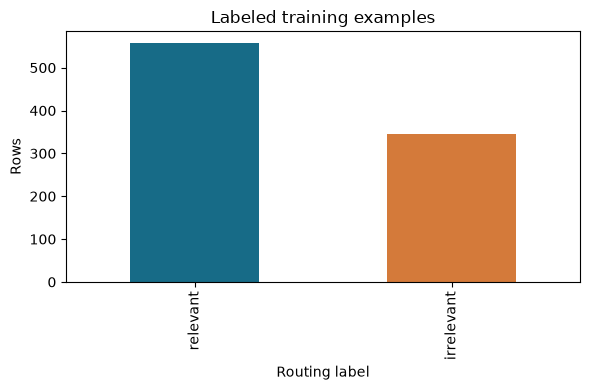

The training file has 903 labeled rows.
     label  rows
  relevant   557
irrelevant   346


In [3]:
DATA_DIR = PROJECT_ROOT / 'intent-classification-assignment' / 'intent-classification-assignment'
train_queries = pd.read_csv(DATA_DIR / 'train_queries.csv')
label_col = 'label'
label_counts = train_queries[label_col].value_counts().rename_axis('label').reset_index(name='rows')
ax = label_counts.plot.bar(x='label', y='rows', legend=False, color=['#176b87', '#d47a3a'], figsize=(6, 4))
ax.set_title('Labeled training examples')
ax.set_xlabel('Routing label')
ax.set_ylabel('Rows')
plt.tight_layout()
plt.savefig(CHART_DIR / 'training_counts.png', dpi=160)
plt.show()
print(f'The training file has {len(train_queries)} labeled rows.')
print(label_counts.to_string(index=False))

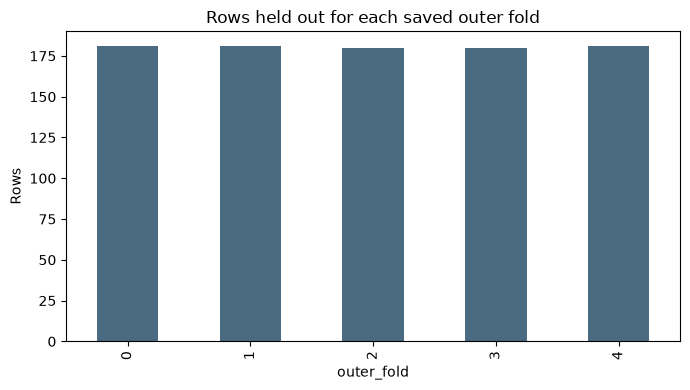

Fold sizes:
outer_fold
0    181
1    181
2    180
3    180
4    181
The plot shows the saved split layout; it does not show model quality.


In [4]:
fold_col = 'outer_fold'
outer_holdout = splits[(splits['split_level'] == 'outer') & (splits['role'] == 'test')]
fold_counts = outer_holdout.groupby(fold_col)['row_index'].nunique().sort_index()
ax = fold_counts.plot.bar(figsize=(7, 4), color='#496a81')
ax.set_title('Rows held out for each saved outer fold')
ax.set_xlabel(fold_col)
ax.set_ylabel('Rows')
plt.tight_layout()
plt.savefig(CHART_DIR / 'outer_fold_sizes.png', dpi=160)
plt.show()
print('Fold sizes:')
print(fold_counts.to_string())
print('The plot shows the saved split layout; it does not show model quality.')

The bars show how many labeled rows belong to each held-out fold. Small differences between bars are expected because the split must respect both class balance and duplicate groups. The important question is whether the outer fold was kept away from fitting and inner selection; that separation is recorded by the core output tables.

## 3. Look at the inner tuning results

The classifier is logistic regression. We compare embeddings A, B, and C, five values of `C`, and unweighted or balanced classes. The inner folds choose among these candidates using average precision, which summarizes the precision and recall trade-off when relevant examples are the class we want to protect.

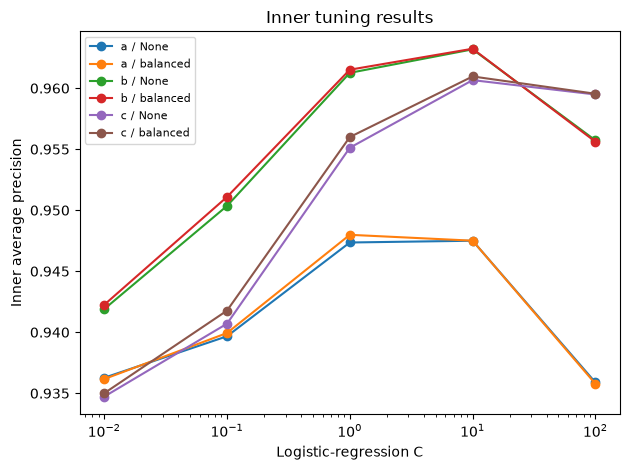

,selection_scope,outer_fold,embedding,C,class_weight,mean_inner_average_precision,inner_average_precision_0,inner_average_precision_1,inner_average_precision_2,inner_rows,selection_rank
0,outer_fold,0,a,0.01,None,0.932342,0.945820,0.909793,0.941413,722,29
1,outer_fold,0,a,0.01,balanced,0.932316,0.945594,0.910238,0.941117,722,30
2,outer_fold,0,a,0.10,None,0.935391,0.948946,0.914388,0.942839,722,26
3,outer_fold,0,a,0.10,balanced,0.935822,0.948716,0.916304,0.942445,722,25
4,outer_fold,0,a,1.00,None,0.942747,0.951599,0.932754,0.943889,722,17
5,outer_fold,0,a,1.00,balanced,0.942857,0.951390,0.933901,0.943281,722,16
6,outer_fold,0,a,10.00,None,0.940708,0.949825,0.940839,0.931460,722,19
7,outer_fold,0,a,10.00,balanced,0.940365,0.949432,0.940687,0.930977,722,20
8,outer_fold,0,a,100.00,None,0.933434,0.945542,0.937825,0.916936,722,27
9,outer_fold,0,a,100.00,balanced,0.933020,0.945317,0.937609,0.916133,722,28


The core selection table above is the evidence for the chosen inner candidate.


In [5]:
candidate_space = candidate_results.copy()
candidate_space['class_weight'] = candidate_space['class_weight'].fillna('None')
candidate_space['C'] = pd.to_numeric(candidate_space['C'], errors='raise')
candidate_space['mean_inner_average_precision'] = pd.to_numeric(candidate_space['mean_inner_average_precision'], errors='raise')
plot_data = candidate_space.groupby(['embedding', 'class_weight', 'C'], as_index=False)['mean_inner_average_precision'].mean()
for (embedding, weight), group in plot_data.groupby(['embedding', 'class_weight']):
    group = group.sort_values('C')
    plt.plot(group['C'], group['mean_inner_average_precision'], marker='o', label=f'{embedding} / {weight}')
plt.xscale('log')
plt.xlabel('Logistic-regression C')
plt.ylabel('Inner average precision')
plt.title('Inner tuning results')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(CHART_DIR / 'tuning_curve.png', dpi=160)
plt.show()
display(candidate_space.head(15))
print('The core selection table above is the evidence for the chosen inner candidate.')

A tuning curve can move up and down as `C` changes. That movement is measured inside the inner folds. It is useful for choosing a recipe, but it is still development evidence; the outer predictions below are the rows that were kept away while each outer-fold choice was made.

## 4. Measure ranking quality with outer-fold ROC and precision-recall curves

A ROC curve shows ranking behavior across many thresholds. A precision-recall curve focuses on the relevant class and is often easier to interpret when the costs of missed relevant queries and unnecessary referrals differ. These curves use out-of-fold predictions from the selected development procedure. They do not use blind test labels.

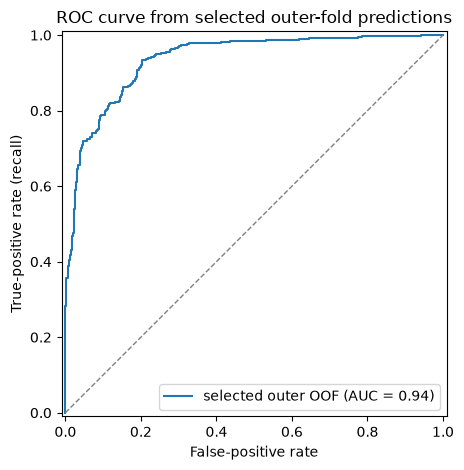

Outer OOF ROC AUC: 0.9366. This is a ranking score: 0.5 is random ranking and 1.0 is perfect ranking; it does not choose the final referral threshold.


In [6]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

y_outer = as_binary(outer_selected['true_label'])
p_outer = outer_selected['p_chosen'].to_numpy()
RocCurveDisplay.from_predictions(y_outer, p_outer, name='selected outer OOF')
plt.plot([0, 1], [0, 1], '--', color='grey', linewidth=1)
plt.xlabel('False-positive rate')
plt.ylabel('True-positive rate (recall)')
plt.title('ROC curve from selected outer-fold predictions')
plt.tight_layout()
plt.savefig(CHART_DIR / 'roc_oof.png', dpi=160)
plt.show()
auc = roc_auc_score(y_outer, p_outer)
print(f'Outer OOF ROC AUC: {auc:.4f}. This is a ranking score: 0.5 is random ranking and 1.0 is perfect ranking; it does not choose the final referral threshold.')

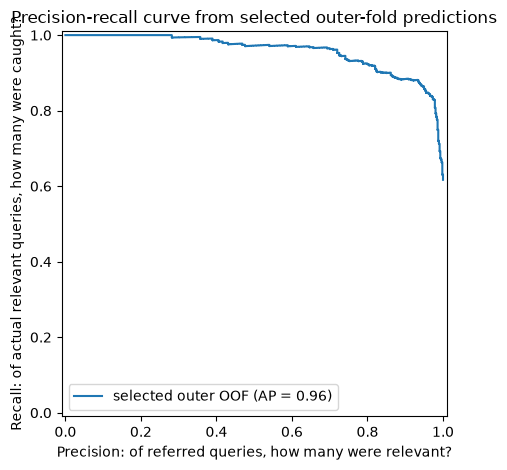

Outer OOF average precision: 0.9584
Positive-class prevalence in these rows: 61.68%
The curve answers how precision changes as we try to catch more actual relevant queries; the operating policy still determines referral workload.


In [7]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

PrecisionRecallDisplay.from_predictions(y_outer, p_outer, name='selected outer OOF')
plt.xlabel('Precision: of referred queries, how many were relevant?')
plt.ylabel('Recall: of actual relevant queries, how many were caught?')
plt.title('Precision-recall curve from selected outer-fold predictions')
plt.tight_layout()
plt.savefig(CHART_DIR / 'precision_recall_oof.png', dpi=160)
plt.show()
print(f'Outer OOF average precision: {average_precision_score(y_outer, p_outer):.4f}')
print(f'Positive-class prevalence in these rows: {y_outer.mean():.2%}')
print('The curve answers how precision changes as we try to catch more actual relevant queries; the operating policy still determines referral workload.')

The curves tell us how well the score ranks examples before we choose one operating threshold. A high ranking score does not guarantee a safe clinical decision. The next section makes the threshold trade-off visible.

## 5. See what happens when we change the threshold

Here, we will see what happens when we change the threshold. A lower threshold sends more queries to the nursing team, which can catch more relevant queries but can also create more unnecessary referrals. A higher threshold may reduce referrals while missing more relevant queries. The sweep is a development diagnostic; the final threshold must come from the predeclared inner selection procedure.

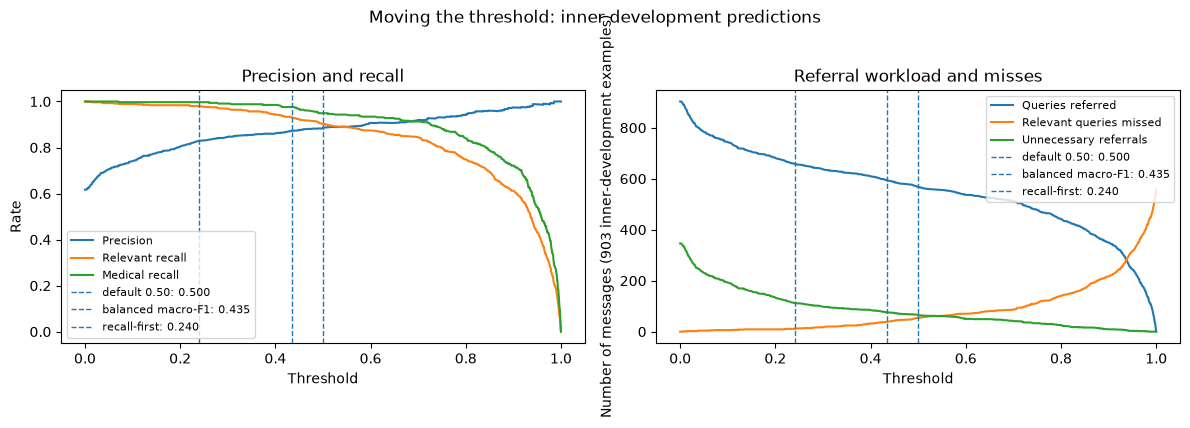

,selection_scope,row_scope,selected_probability_method,threshold,accuracy,macro_f1,precision,relevant_recall,specificity,tp,...,fp,fn,medical_fn,medical_n,medical_recall,referral_fraction,feasible_recall_first,selected_default_0_5,selected_balanced_macro_f1,selected_recall_first
0,final_all_training,inner_development,sigmoid,0.000000,0.616833,0.381507,0.616833,1.0,0.000000,557,...,346,0,0,334,1.0,1.000000,True,False,False,False
1,final_all_training,inner_development,sigmoid,0.002113,0.616833,0.381507,0.616833,1.0,0.000000,557,...,346,0,0,334,1.0,1.000000,True,False,False,False
2,final_all_training,inner_development,sigmoid,0.002825,0.617940,0.384650,0.617517,1.0,0.002890,557,...,345,0,0,334,1.0,0.998893,True,False,False,False
3,final_all_training,inner_development,sigmoid,0.003055,0.619048,0.387777,0.618202,1.0,0.005780,557,...,344,0,0,334,1.0,0.997785,True,False,False,False
4,final_all_training,inner_development,sigmoid,0.003717,0.620155,0.390888,0.618889,1.0,0.008671,557,...,343,0,0,334,1.0,0.996678,True,False,False,False
5,final_all_training,inner_development,sigmoid,0.003987,0.621262,0.393984,0.619577,1.0,0.011561,557,...,342,0,0,334,1.0,0.995570,True,False,False,False
6,final_all_training,inner_development,sigmoid,0.004463,0.622370,0.397063,0.620267,1.0,0.014451,557,...,341,0,0,334,1.0,0.994463,True,False,False,False
7,final_all_training,inner_development,sigmoid,0.004994,0.623477,0.400127,0.620959,1.0,0.017341,557,...,340,0,0,334,1.0,0.993355,True,False,False,False
8,final_all_training,inner_development,sigmoid,0.005159,0.624585,0.403175,0.621652,1.0,0.020231,557,...,339,0,0,334,1.0,0.992248,True,False,False,False
9,final_all_training,inner_development,sigmoid,0.005211,0.625692,0.406208,0.622346,1.0,0.023121,557,...,338,0,0,334,1.0,0.991141,True,False,False,False


Every row above is an inner-development operating point. It is used to freeze the three policy thresholds before outer-fold checking.
Precision is omitted at thresholds with no referred queries because it is undefined there; the right panel uses message counts for referrals, misses, and unnecessary referrals.


In [8]:
threshold_col = 'threshold'
threshold_sweep[threshold_col] = pd.to_numeric(threshold_sweep[threshold_col], errors='raise')
threshold_sweep = threshold_sweep.sort_values(threshold_col).reset_index(drop=True)
thresholds = threshold_sweep[threshold_col].to_numpy()
precision = pd.to_numeric(threshold_sweep['precision'], errors='raise')
recall = pd.to_numeric(threshold_sweep['relevant_recall'], errors='raise')
medical_recall = pd.to_numeric(threshold_sweep['medical_recall'], errors='raise')
referrals = threshold_sweep['tp'].astype(int) + threshold_sweep['fp'].astype(int)
relevant_misses = threshold_sweep['fn'].astype(int)
unnecessary_referrals = threshold_sweep['fp'].astype(int)
precision_for_plot = precision.where(referrals > 0, np.nan)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Moving the threshold: inner development predictions')
axes[0].plot(thresholds, precision_for_plot, label='Precision')
axes[0].plot(thresholds, recall, label='Relevant recall')
axes[0].plot(thresholds, medical_recall, label='Medical recall')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Rate')
axes[0].set_title('Precision and recall')
axes[0].legend()
axes[1].plot(thresholds, referrals, label='Queries referred')
axes[1].plot(thresholds, relevant_misses, label='Relevant queries missed')
axes[1].plot(thresholds, unnecessary_referrals, label='Unnecessary referrals')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Number of messages (903 inner-development examples)')
axes[1].set_title('Referral workload and misses')
axes[1].legend()
policy_markers = {'default 0.50': 'selected_default_0_5', 'balanced macro-F1': 'selected_balanced_macro_f1', 'recall-first': 'selected_recall_first'}
for label, flag_column in policy_markers.items():
    flags = threshold_sweep[flag_column].astype(str).str.lower().isin(['true', '1', 'yes'])
    if int(flags.sum()) != 1:
        raise ValueError(f'threshold_sweep.csv must mark exactly one {label} threshold; found {int(flags.sum())}')
    policy_threshold = float(threshold_sweep.loc[flags, threshold_col].iloc[0])
    for axis in axes:
        axis.axvline(policy_threshold, linestyle='--', linewidth=1, label=f'{label}: {policy_threshold:.3f}')
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(CHART_DIR / 'threshold_tradeoffs.png', dpi=160)
plt.show()
display(threshold_sweep.head(12))
print('Every row above is an inner-development operating point. It is used to freeze the three policy thresholds before outer-fold checking.')
print('Precision is omitted at thresholds with no referred queries because it is undefined there; the right panel uses message counts for referrals, misses, and unnecessary referrals.')

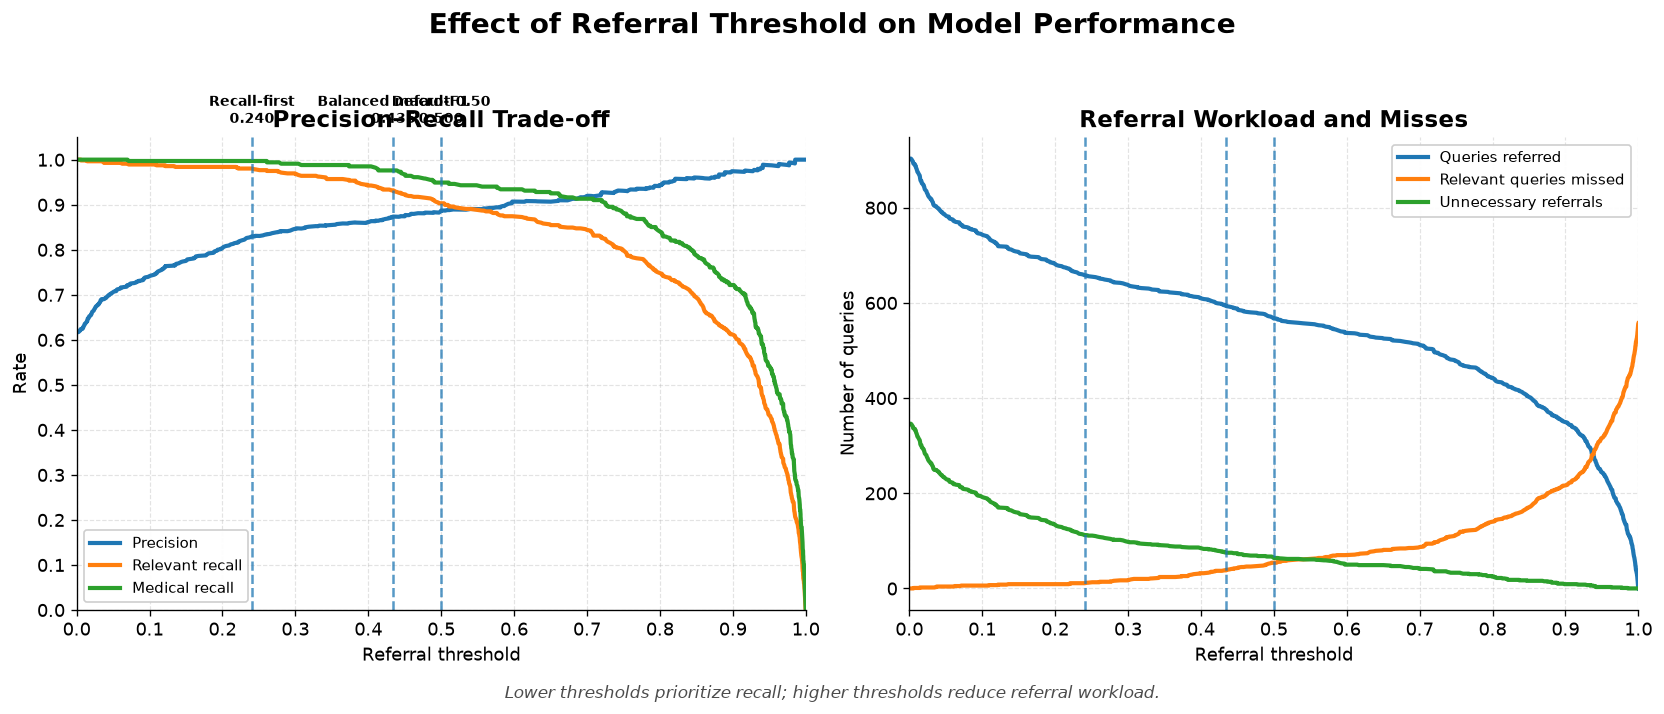

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------
# Prepare data
# -----------------------------
threshold_col = 'threshold'

threshold_sweep[threshold_col] = pd.to_numeric(
    threshold_sweep[threshold_col],
    errors='raise'
)

threshold_sweep = (
    threshold_sweep
    .sort_values(threshold_col)
    .reset_index(drop=True)
)

thresholds = threshold_sweep[threshold_col].to_numpy()

precision = pd.to_numeric(
    threshold_sweep['precision'], errors='raise'
)

recall = pd.to_numeric(
    threshold_sweep['relevant_recall'], errors='raise'
)

medical_recall = pd.to_numeric(
    threshold_sweep['medical_recall'], errors='raise'
)

referrals = (
    threshold_sweep['tp'].astype(int)
    + threshold_sweep['fp'].astype(int)
)

relevant_misses = threshold_sweep['fn'].astype(int)
unnecessary_referrals = threshold_sweep['fp'].astype(int)

# Precision is undefined if nothing is referred
precision_for_plot = precision.where(referrals > 0, np.nan)


# -----------------------------
# Plot styling
# -----------------------------
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5.5),
    dpi=120
)

fig.suptitle(
    'Effect of Referral Threshold on Model Performance',
    fontsize=17,
    fontweight='bold',
    y=1.02
)


# =========================================================
# LEFT: Precision / Recall
# =========================================================
ax = axes[0]

ax.plot(
    thresholds,
    precision_for_plot,
    linewidth=2.5,
    label='Precision'
)

ax.plot(
    thresholds,
    recall,
    linewidth=2.5,
    label='Relevant recall'
)

ax.plot(
    thresholds,
    medical_recall,
    linewidth=2.5,
    label='Medical recall'
)

ax.set_title(
    'Precision–Recall Trade-off',
    fontweight='bold'
)

ax.set_xlabel('Referral threshold')
ax.set_ylabel('Rate')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)

ax.set_xticks(np.arange(0, 1.01, 0.1))
ax.set_yticks(np.arange(0, 1.01, 0.1))

ax.grid(
    True,
    which='major',
    linestyle='--',
    linewidth=0.7,
    alpha=0.35
)

ax.legend(
    loc='lower left',
    frameon=True,
    framealpha=0.95
)


# =========================================================
# RIGHT: Workload
# =========================================================
ax = axes[1]

ax.plot(
    thresholds,
    referrals,
    linewidth=2.5,
    label='Queries referred'
)

ax.plot(
    thresholds,
    relevant_misses,
    linewidth=2.5,
    label='Relevant queries missed'
)

ax.plot(
    thresholds,
    unnecessary_referrals,
    linewidth=2.5,
    label='Unnecessary referrals'
)

ax.set_title(
    'Referral Workload and Misses',
    fontweight='bold'
)

ax.set_xlabel('Referral threshold')
ax.set_ylabel('Number of queries')

ax.set_xlim(0, 1)

ax.set_xticks(np.arange(0, 1.01, 0.1))

ax.grid(
    True,
    which='major',
    linestyle='--',
    linewidth=0.7,
    alpha=0.35
)

ax.legend(
    loc='upper right',
    frameon=True,
    framealpha=0.95
)


# =========================================================
# Policy threshold markers
# =========================================================
policy_markers = {
    'Recall-first': 'selected_recall_first',
    'Balanced macro-F1': 'selected_balanced_macro_f1',
    'Default 0.50': 'selected_default_0_5'
}


for i, (label, flag_column) in enumerate(policy_markers.items()):

    flags = (
        threshold_sweep[flag_column]
        .astype(str)
        .str.lower()
        .isin(['true', '1', 'yes'])
    )

    if int(flags.sum()) != 1:
        raise ValueError(
            f'{flag_column} must contain exactly one selected threshold; '
            f'found {int(flags.sum())}'
        )

    policy_threshold = float(
        threshold_sweep.loc[flags, threshold_col].iloc[0]
    )

    # Add line to both charts
    for ax in axes:
        ax.axvline(
            policy_threshold,
            linestyle='--',
            linewidth=1.5,
            alpha=0.75
        )

    # Label threshold at top of LEFT plot
    axes[0].text(
        policy_threshold,
        1.02,
        f'{label}\n{policy_threshold:.3f}',
        transform=axes[0].get_xaxis_transform(),
        ha='center',
        va='bottom',
        fontsize=8.5,
        fontweight='bold'
    )


# -----------------------------
# Final formatting
# -----------------------------
fig.text(
    0.5,
    -0.02,
    'Lower thresholds prioritize recall; higher thresholds reduce referral workload.',
    ha='center',
    fontsize=10,
    style='italic',
    alpha=0.7
)

plt.tight_layout()

plt.savefig(
    CHART_DIR / 'threshold_tradeoffs_beautiful.png',
    dpi=200,
    bbox_inches='tight'
)

plt.show()

The three policies are explicit: `default` uses threshold 0.50, `balanced` is the threshold that maximizes development macro-F1, and `recall-first` is the highest threshold that meets the assumed 98% relevant-recall and 99% Medical-recall targets when feasible. The threshold sweep is inner-fold development evidence only. The targets are assumptions to investigate, not guarantees about future messages.

## 6. Compare three operating points with confusion matrices

A confusion matrix counts four outcomes: relevant queries sent onward, relevant queries missed, irrelevant queries sent onward, and irrelevant queries withheld. We will compare the three named policies: `default`, `balanced`, and `recall-first`. Each decision column was saved by the corresponding outer-fold model using that fold's frozen policy threshold. This code reads those saved decisions; it does not apply one final threshold to pooled outer probabilities.

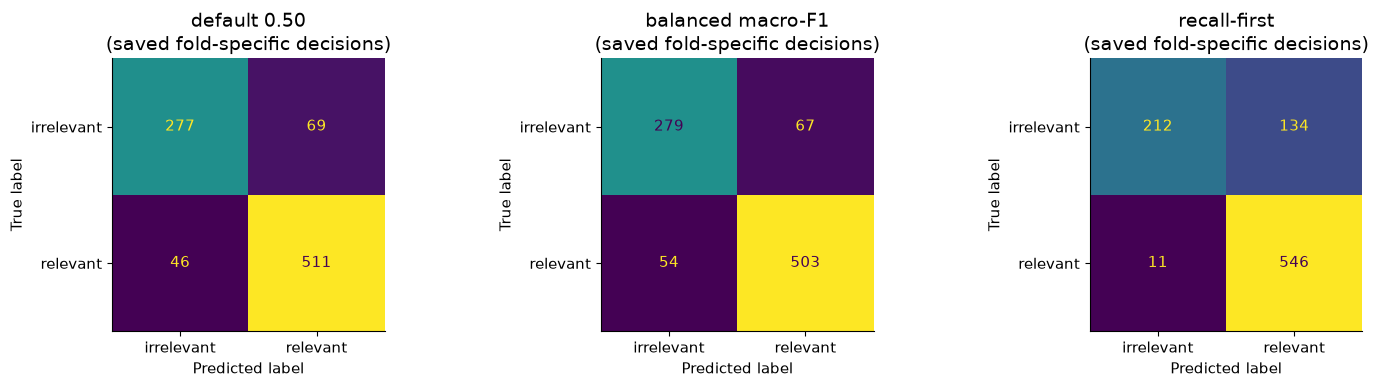

Operating points shown: ['default 0.50', 'balanced macro-F1', 'recall-first']
Counts come from saved held-out outer-fold decisions and are development evidence.
default_0_5: FN=46, FP=69, Medical FN=14/334, macro-F1=86.3479%.
balanced_macro_f1: FN=54, FP=67, Medical FN=18/334, macro-F1=85.7216%.
recall_first: FN=11, FP=134, Medical FN=1/334, macro-F1=81.3974%.


In [10]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

operating_points = [('default 0.50', 'label_default_0_5'), ('balanced macro-F1', 'label_balanced_macro_f1'), ('recall-first', 'label_recall_first')]
fig, axes = plt.subplots(1, len(operating_points), figsize=(5 * len(operating_points), 4))
axes = np.atleast_1d(axes)
for axis, (label, decision_column) in zip(axes, operating_points):
    predicted = as_binary(outer_selected[decision_column])
    matrix = confusion_matrix(y_outer, predicted, labels=[0, 1])
    ConfusionMatrixDisplay(matrix, display_labels=['irrelevant', 'relevant']).plot(ax=axis, colorbar=False)
    axis.set_title(f'{label}\n(saved fold-specific decisions)')
plt.tight_layout()
plt.savefig(CHART_DIR / 'confusion_operating_points.png', dpi=160)
plt.show()
print('Operating points shown:', [label for label, _ in operating_points])
print('Counts come from saved held-out outer-fold decisions and are development evidence.')
policy_metrics = metrics[metrics['system'].eq('tuned_lr') & metrics['evaluation'].eq('outer_oof_aggregate')].set_index('policy')
for policy in ['default_0_5', 'balanced_macro_f1', 'recall_first']:
    row = policy_metrics.loc[policy]
    print(f"{policy}: FN={int(row['fn'])}, FP={int(row['fp'])}, Medical FN={int(row['medical_fn'])}/{int(row['medical_n'])}, macro-F1={row['macro_f1']:.4%}.")

| Policy | Relevant missed | Unnecessary referrals | Relevant recall | Medical missed | Total workload |
|---|---:|---:|---:|---:|---:|
| Default 0.50 | **46** | 69 | ~91.7% | 14 / 334 | **580 referrals** |
| Balanced macro-F1 | **54** | **67** | ~90.3% | 18 / 334 | **570 referrals** |
| Recall-first | **11** | 134 | **~98.0%** | **1 / 334** | **680 referrals** |

## 7. Check whether the probabilities are calibrated

A probability of 0.80 should mean that roughly 80 out of 100 similar examples are relevant if the probabilities are well calibrated. We compare the raw logistic-regression score with the selected score when the core saved both. The Brier score is lower when probability errors are smaller. A calibration plot is a diagnostic, not proof that a score is safe for clinical use.

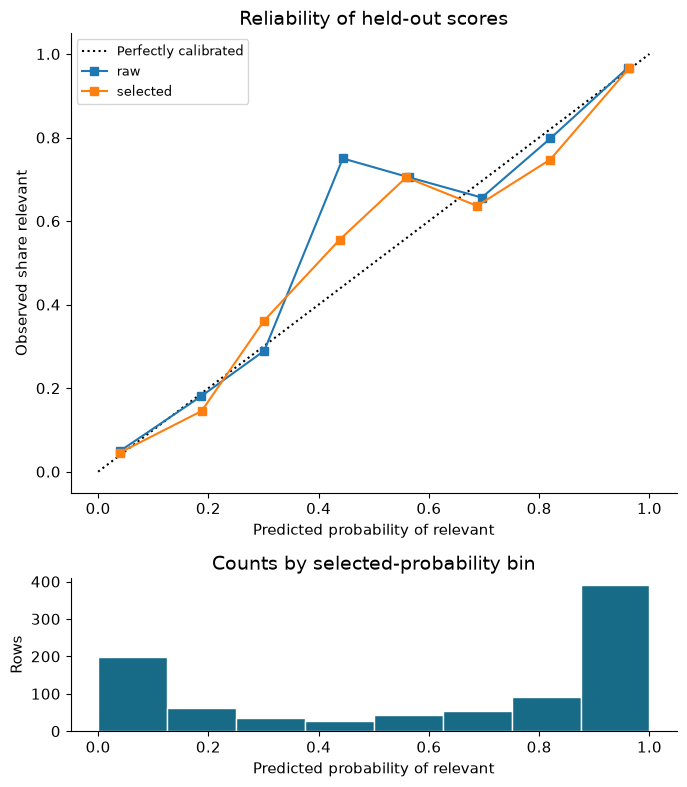

,bin,rows,mean_predicted_probability,observed_share_relevant
0,"(-0.001, 0.125]",198,0.039130,0.045455
1,"(0.125, 0.25]",62,0.187665,0.145161
2,"(0.25, 0.375]",36,0.300733,0.361111
3,"(0.375, 0.5]",27,0.438130,0.555556
4,"(0.5, 0.625]",44,0.558828,0.704545
5,"(0.625, 0.75]",55,0.687241,0.636364
6,"(0.75, 0.875]",91,0.820096,0.747253
7,"(0.875, 1.0]",390,0.963371,0.966667


raw Brier score: 0.0964
selected Brier score: 0.0945
The selected held-out score has a lower Brier score than the raw score in this run.


In [11]:
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss

raw_col = 'p_raw'
calibrated_col = 'p_chosen'
fig, axes = plt.subplots(2, 1, figsize=(7, 8), gridspec_kw={'height_ratios': [3, 1]})
for column, label in [(raw_col, 'raw'), (calibrated_col, 'selected')]:
    probabilities = pd.to_numeric(outer_selected[column], errors='coerce').to_numpy()
    CalibrationDisplay.from_predictions(y_outer, probabilities, n_bins=8, name=label, ax=axes[0])
axes[0].set_title('Reliability of held-out scores')
axes[0].set_xlabel('Predicted probability of relevant')
axes[0].set_ylabel('Observed share relevant')
axes[0].legend()
selected_probabilities = pd.to_numeric(outer_selected[calibrated_col], errors='coerce')
axes[1].hist(selected_probabilities, bins=np.linspace(0, 1, 9), color='#176b87', edgecolor='white')
axes[1].set_title('Counts by selected-probability bin')
axes[1].set_xlabel('Predicted probability of relevant')
axes[1].set_ylabel('Rows')
plt.tight_layout()
plt.savefig(CHART_DIR / 'calibration_reliability.png', dpi=160)
plt.show()
calibration_bins = pd.DataFrame({'bin': pd.cut(selected_probabilities, bins=np.linspace(0, 1, 9), include_lowest=True), 'predicted_probability': selected_probabilities, 'observed_relevant': y_outer}).groupby('bin', observed=False).agg(rows=('observed_relevant', 'size'), mean_predicted_probability=('predicted_probability', 'mean'), observed_share_relevant=('observed_relevant', 'mean')).reset_index()
display(calibration_bins)
brier_values = {}
for column, label in [(raw_col, 'raw'), (calibrated_col, 'selected')]:
    probabilities = pd.to_numeric(outer_selected[column], errors='coerce').to_numpy()
    brier_values[label] = brier_score_loss(y_outer, probabilities)
    print(f'{label} Brier score: {brier_values[label]:.4f}')
print(f"The selected held-out score has a {'lower' if brier_values['selected'] < brier_values['raw'] else 'higher or equal'} Brier score than the raw score in this run.")

Calibration can change a score without changing the underlying ranking. We therefore keep calibration results separate from threshold results. If the raw and selected Brier scores are close, the calibration step made little measured difference on these held-out rows; if they differ, the selected score should be the one used by the documented policy.

## 8. Compare measured scores and inspect the blind-test file

The comparison table contains measured scores for the current ABC logistic-regression candidates and the supplied LLM label-only baseline. The LLM has labels only; it has no probability score, so it appears in score tables and bars only. The test file is only an inference artifact because its true labels are absent.

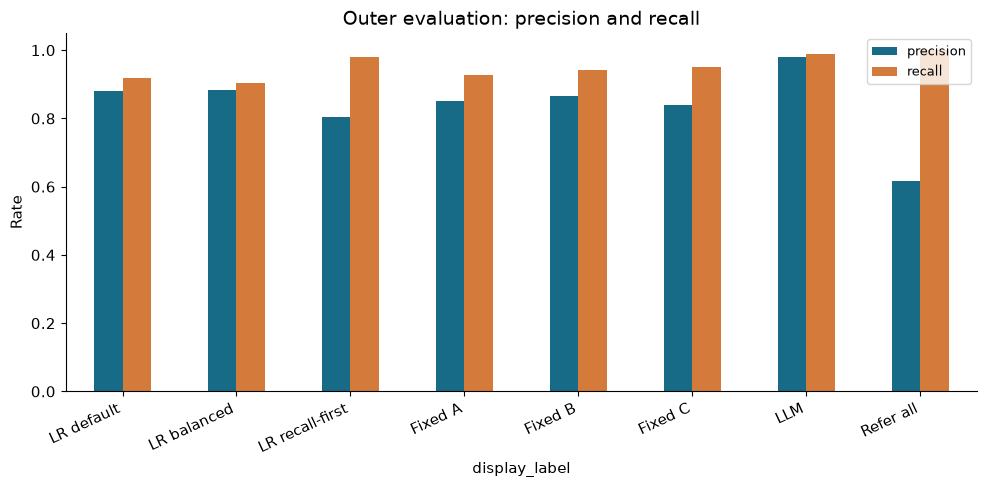

,display_label,policy,accuracy,macro_f1,precision,recall,medical_recall,average_precision,fn,fp,medical_fn,medical_n
0,LR default,default_0_5,87.26%,86.35%,88.10%,91.74%,95.81%,0.9584,46,69,14,334
6,LR balanced,balanced_macro_f1,86.60%,85.72%,88.25%,90.31%,94.61%,0.9584,54,67,18,334
12,LR recall-first,recall_first,83.94%,81.40%,80.29%,98.03%,99.70%,0.9584,11,134,1,334
18,Fixed A,default_0_5,85.38%,84.05%,85.01%,92.64%,98.20%,0.9502,41,91,6,334
24,Fixed B,default_0_5,87.38%,86.22%,86.49%,94.25%,98.80%,0.9625,32,82,4,334
30,Fixed C,default_0_5,85.60%,84.01%,83.84%,94.97%,99.10%,0.9556,28,102,3,334
36,LLM,frozen_label,97.90%,97.77%,97.86%,98.74%,100.00%,NaN,7,12,0,334
37,Refer all,always_relevant,61.68%,38.15%,61.68%,100.00%,100.00%,NaN,0,346,0,334


,policy,recall_min,recall_max,macro_f1_min,macro_f1_max,fn_min,fn_max,medical_fn_min,medical_fn_max
0,balanced_macro_f1,86.49%,95.54%,81.26%,87.80%,5,15,1,8
1,default_0_5,88.39%,95.54%,82.23%,88.60%,5,13,1,6
2,recall_first,94.64%,99.11%,76.47%,87.35%,1,6,0,1


The compact table uses one aggregate row per system/policy; the fold table shows variation only for the three tuned policies.
Test prediction rows: 904
Unique test IDs: 904
No test quality metric is calculated because the blind test labels are unavailable.
default_0_5: accuracy=87.2647%, macro-F1=86.3479%, precision=88.1034%, recall=91.7415%, FN=46, FP=69, Medical FN=14/334, referral fraction=64.23%.
balanced_macro_f1: accuracy=86.6002%, macro-F1=85.7216%, precision=88.2456%, recall=90.3052%, FN=54, FP=67, Medical FN=18/334, referral fraction=63.12%.
recall_first: accuracy=83.9424%, macro-F1=81.3974%, precision=80.2941%, recall=98.0251%, FN=11, FP=134, Medical FN=1/334, referral fraction=75.30%.
Fair fixed B baseline: accuracy=87.3754%, AP=0.9625, recall=94.2549%.
Label-only LLM baseline: accuracy=97.8959%, FN=7, FP=12, Medical FN=0/334; ROC-AUC and AP are undefined.


In [12]:
comparison_metrics = metrics[metrics['evaluation'].eq('outer_oof_aggregate')].copy()
display_columns = ['system', 'policy', 'accuracy', 'macro_f1', 'precision', 'recall', 'medical_recall', 'average_precision', 'fn', 'fp', 'medical_fn', 'medical_n']
comparison_metrics['display_label'] = comparison_metrics['system'] + ' / ' + comparison_metrics['policy']
label_map = {'tuned_lr / default_0_5': 'LR default', 'tuned_lr / balanced_macro_f1': 'LR balanced', 'tuned_lr / recall_first': 'LR recall-first', 'baseline_lr_a / default_0_5': 'Fixed A', 'baseline_lr_b / default_0_5': 'Fixed B', 'baseline_lr_c / default_0_5': 'Fixed C', 'llm_train / frozen_label': 'LLM', 'always_relevant / always_relevant': 'Refer all'}
comparison_metrics['display_label'] = comparison_metrics['display_label'].map(label_map).fillna(comparison_metrics['display_label'])
plot_metrics = comparison_metrics.set_index('display_label')[['precision', 'recall']].apply(pd.to_numeric, errors='raise')
plot_metrics.plot.bar(figsize=(10, 5), color=['#176b87', '#d47a3a'])
plt.title('Outer evaluation: precision and recall')
plt.ylabel('Rate')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(CHART_DIR / 'comparison_scores.png', dpi=160)
plt.show()
compact_table = comparison_metrics.copy()
compact_table = compact_table.assign(average_precision=compact_table['average_precision'].round(4), accuracy=compact_table['accuracy'].map(lambda value: f'{value:.2%}'), macro_f1=compact_table['macro_f1'].map(lambda value: f'{value:.2%}'), precision=compact_table['precision'].map(lambda value: f'{value:.2%}'), recall=compact_table['recall'].map(lambda value: f'{value:.2%}'), medical_recall=compact_table['medical_recall'].map(lambda value: f'{value:.2%}'))
display(compact_table[['display_label', 'policy', 'accuracy', 'macro_f1', 'precision', 'recall', 'medical_recall', 'average_precision', 'fn', 'fp', 'medical_fn', 'medical_n']])
fold_metrics = metrics[metrics['system'].eq('tuned_lr') & metrics['evaluation'].str.startswith('outer_fold_')].copy()
fold_summary = fold_metrics.groupby('policy').agg(recall_min=('recall', 'min'), recall_max=('recall', 'max'), macro_f1_min=('macro_f1', 'min'), macro_f1_max=('macro_f1', 'max'), fn_min=('fn', 'min'), fn_max=('fn', 'max'), medical_fn_min=('medical_fn', 'min'), medical_fn_max=('medical_fn', 'max')).reset_index()
for column in ['recall_min', 'recall_max', 'macro_f1_min', 'macro_f1_max']:
    fold_summary[column] = fold_summary[column].map(lambda value: f'{value:.2%}')
display(fold_summary)
print('The compact table uses one aggregate row per system/policy; the fold table shows variation only for the three tuned policies.')
print(f'Test prediction rows: {len(test_predictions)}')
test_id_col = 'query_id'
print(f'Unique test IDs: {test_predictions[test_id_col].nunique()}')
print('No test quality metric is calculated because the blind test labels are unavailable.')

tuned = metrics[metrics['system'].eq('tuned_lr') & metrics['evaluation'].eq('outer_oof_aggregate')].set_index('policy')
for policy in ['default_0_5', 'balanced_macro_f1', 'recall_first']:
    row = tuned.loc[policy]
    print(f"{policy}: accuracy={row['accuracy']:.4%}, macro-F1={row['macro_f1']:.4%}, precision={row['precision']:.4%}, recall={row['recall']:.4%}, FN={int(row['fn'])}, FP={int(row['fp'])}, Medical FN={int(row['medical_fn'])}/{int(row['medical_n'])}, referral fraction={row['referral_fraction']:.2%}.")
fixed_b = metrics[metrics['system'].eq('baseline_lr_b') & metrics['policy'].eq('default_0_5') & metrics['evaluation'].eq('outer_oof_aggregate')].iloc[0]
llm = metrics[metrics['system'].eq('llm_train') & metrics['evaluation'].eq('outer_oof_aggregate')].iloc[0]
print(f"Fair fixed B baseline: accuracy={fixed_b['accuracy']:.4%}, AP={fixed_b['average_precision']:.4f}, recall={fixed_b['recall']:.4%}.")
print(f"Label-only LLM baseline: accuracy={llm['accuracy']:.4%}, FN={int(llm['fn'])}, FP={int(llm['fp'])}, Medical FN={int(llm['medical_fn'])}/{int(llm['medical_n'])}; ROC-AUC and AP are undefined.")

The current run shows a clear distinction between the search objective and the final operating scores. The tuned default policy measured 87.26% accuracy and 0.9584 average precision, while the fair fixed B baseline measured 87.38% accuracy and 0.9625 average precision on the same outer folds. The tuned default therefore does not beat fixed B on accuracy or ranking AP.

The recall-first policy measured 98.03% relevant recall with 11 relevant misses, 134 false positives, and 1 Medical miss out of 334 Medical rows. The default policy measured 46 relevant misses, 69 false positives, and 14 Medical misses out of 334. The balanced macro-F1 policy was worse than default on the outer folds for macro-F1 (85.72% versus 86.35%) and relevant recall (90.31% versus 91.74%), so it is not described as an outer winner.

The supplied LLM has labels only. On the same 903 rows it measured 97.90% accuracy, 7 relevant misses, 12 false positives, and 0 Medical misses out of 334; ROC-AUC and AP are undefined because no LLM probability score was supplied. These are observed development results, and they do not promise improvement, future recall, or clinical performance.

In [13]:
from IPython.display import display, HTML
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd
import numpy as np


# ============================================================
# 1. COLLECT SUMMARY METRICS
# ============================================================

# Training data
n_train = len(train_queries)

n_relevant = int(
    (train_queries[label_col] == 'relevant').sum()
)

n_irrelevant = int(
    (train_queries[label_col] == 'irrelevant').sum()
)


# Outer OOF ranking metrics
outer_auc = roc_auc_score(y_outer, p_outer)

outer_ap = average_precision_score(
    y_outer,
    p_outer
)


# Number of outer folds
n_outer_folds = outer_holdout[fold_col].nunique()


# ============================================================
# 2. FIND BEST AGGREGATE INNER CANDIDATE
# ============================================================

summary_candidate_space = candidate_results.copy()

summary_candidate_space['class_weight'] = (
    summary_candidate_space['class_weight']
    .fillna('None')
)

summary_candidate_space['C'] = pd.to_numeric(
    summary_candidate_space['C'],
    errors='raise'
)

summary_candidate_space['mean_inner_average_precision'] = pd.to_numeric(
    summary_candidate_space['mean_inner_average_precision'],
    errors='raise'
)


aggregate_candidates = (
    summary_candidate_space
    .groupby(
        [
            'embedding',
            'class_weight',
            'C'
        ],
        as_index=False
    )['mean_inner_average_precision']
    .mean()
)


best_candidate = (
    aggregate_candidates
    .sort_values(
        'mean_inner_average_precision',
        ascending=False
    )
    .iloc[0]
)


best_embedding = best_candidate['embedding']
best_weight = best_candidate['class_weight']
best_C = float(best_candidate['C'])

best_inner_ap = float(
    best_candidate['mean_inner_average_precision']
)


# ============================================================
# 3. POLICY METRICS
# ============================================================

policy_metrics = (
    metrics[
        metrics['system'].eq('tuned_lr')
        &
        metrics['evaluation'].eq(
            'outer_oof_aggregate'
        )
    ]
    .set_index('policy')
)


policy_names = {
    'default_0_5': 'Default 0.50',
    'balanced_macro_f1': 'Balanced macro-F1',
    'recall_first': 'Recall-first'
}


policy_rows = []


for policy_id, display_name in policy_names.items():

    row = policy_metrics.loc[policy_id]

    tp = int(row['tp'])
    fp = int(row['fp'])
    fn = int(row['fn'])

    medical_fn = int(row['medical_fn'])
    medical_n = int(row['medical_n'])

    workload = tp + fp

    recall_value = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    precision_value = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else np.nan
    )

    medical_recall_value = (
        (medical_n - medical_fn) / medical_n
        if medical_n > 0
        else np.nan
    )

    policy_rows.append({
        'Policy': display_name,
        'Relevant missed': fn,
        'Unnecessary referrals': fp,
        'Total workload': workload,
        'Precision': precision_value,
        'Relevant recall': recall_value,
        'Medical missed': medical_fn,
        'Medical total': medical_n,
        'Medical recall': medical_recall_value,
        'Macro F1': float(row['macro_f1'])
    })


policy_df = pd.DataFrame(policy_rows)


default_row = policy_df[
    policy_df['Policy'] == 'Default 0.50'
].iloc[0]


balanced_row = policy_df[
    policy_df['Policy'] == 'Balanced macro-F1'
].iloc[0]


recall_row = policy_df[
    policy_df['Policy'] == 'Recall-first'
].iloc[0]


# ============================================================
# 4. CALCULATE POLICY DIFFERENCES
# ============================================================

workload_increase = (
    recall_row['Total workload']
    - default_row['Total workload']
)


workload_increase_pct = (
    workload_increase
    / default_row['Total workload']
)


relevant_misses_reduced = (
    default_row['Relevant missed']
    - recall_row['Relevant missed']
)


medical_misses_reduced = (
    default_row['Medical missed']
    - recall_row['Medical missed']
)


# ============================================================
# 5. BUILD POLICY TABLE ROWS
# ============================================================

policy_table_rows = ""


for _, row in policy_df.iterrows():

    highlight = (
        'recall-highlight'
        if row['Policy'] == 'Recall-first'
        else ''
    )

    policy_table_rows += f"""
    <tr class="{highlight}">
        <td>
            <strong>{row['Policy']}</strong>
        </td>

        <td>
            {int(row['Relevant missed'])}
        </td>

        <td>
            {int(row['Unnecessary referrals'])}
        </td>

        <td>
            {int(row['Total workload'])}
        </td>

        <td>
            {row['Precision']:.1%}
        </td>

        <td>
            {row['Relevant recall']:.1%}
        </td>

        <td>
            {int(row['Medical missed'])}
            /
            {int(row['Medical total'])}
        </td>

        <td>
            {row['Medical recall']:.1%}
        </td>

        <td>
            {row['Macro F1']:.1%}
        </td>
    </tr>
    """


# ============================================================
# 6. EXECUTIVE SUMMARY HTML
# ============================================================

html = f"""
<style>

/* =========================================================
   MAIN REPORT
   ========================================================= */

.exec-report {{

    font-family:
        -apple-system,
        BlinkMacSystemFont,
        "Segoe UI",
        Arial,
        sans-serif;

    max-width: 1200px;

    margin: 20px auto;

    background: #ffffff !important;

    color: #1f2937 !important;

    padding: 42px 48px;

    border-radius: 14px;

    line-height: 1.6;

    box-sizing: border-box;

    box-shadow:
        0 6px 25px rgba(0, 0, 0, 0.08);
}}


/* FORCE DARK TEXT EVEN IN VS CODE DARK MODE */

.exec-report p,
.exec-report li,
.exec-report td,
.exec-report span {{

    color: #1f2937 !important;
}}


/* =========================================================
   HEADINGS
   ========================================================= */

.exec-report h1 {{

    font-size: 31px;

    margin-top: 0;

    margin-bottom: 4px;

    color: #123447 !important;

    font-weight: 750;
}}


.exec-report h2 {{

    font-size: 22px;

    color: #123447 !important;

    margin-top: 34px;

    margin-bottom: 14px;

    padding-bottom: 7px;

    border-bottom:
        2px solid #dce4e8;

    font-weight: 700;
}}


.exec-report h3 {{

    font-size: 17px;

    color: #123447 !important;

    margin-top: 0;

    margin-bottom: 8px;
}}


.subtitle {{

    font-size: 15px;

    color: #64748b !important;

    margin-bottom: 28px;
}}


/* =========================================================
   EXECUTIVE TAKEAWAY
   ========================================================= */

.hero {{

    background:
        linear-gradient(
            135deg,
            #eef7fa,
            #ffffff
        ) !important;

    border:
        1px solid #d6e5eb;

    border-radius: 14px;

    padding: 25px 28px;

    margin-bottom: 26px;
}}


.hero-title {{

    font-size: 21px;

    font-weight: 750;

    color: #123447 !important;

    margin-bottom: 9px;
}}


.hero-text {{

    font-size: 16px;

    color: #1f2937 !important;

    margin: 0;
}}


/* =========================================================
   METRIC CARDS
   ========================================================= */

.metric-grid {{

    display: grid;

    grid-template-columns:
        repeat(4, 1fr);

    gap: 15px;

    margin:
        20px 0 30px 0;
}}


.metric-card {{

    border:
        1px solid #e2e8f0;

    border-radius: 12px;

    padding: 19px;

    background:
        #ffffff !important;

    box-shadow:
        0 3px 9px
        rgba(0, 0, 0, 0.06);
}}


.metric-value {{

    font-size: 29px;

    font-weight: 750;

    color: #176b87 !important;
}}


.metric-label {{

    font-size: 12px;

    color: #64748b !important;

    margin-top: 4px;
}}


/* =========================================================
   EXPERIMENT FLOW
   ========================================================= */

.flow {{

    text-align: center;

    font-weight: 650;

    color: #334155 !important;

    background:
        #f8fafc !important;

    border:
        1px solid #e2e8f0;

    border-radius: 10px;

    padding: 17px;

    margin: 18px 0 22px 0;

    font-size: 15px;
}}


/* =========================================================
   TWO COLUMN CARDS
   ========================================================= */

.two-col {{

    display: grid;

    grid-template-columns:
        1fr 1fr;

    gap: 22px;

    margin-top: 18px;
}}


.box {{

    border:
        1px solid #e2e8f0;

    border-radius: 12px;

    padding: 21px;

    background:
        #ffffff !important;

    box-shadow:
        0 3px 9px
        rgba(0, 0, 0, 0.05);
}}


.box p {{

    margin-bottom: 0;

    color: #334155 !important;
}}


/* =========================================================
   NORMAL CALLOUT
   ========================================================= */

.callout {{

    border-left:
        5px solid #176b87;

    background:
        #f2f8fa !important;

    padding:
        17px 20px;

    margin:
        20px 0;

    border-radius:
        4px 10px 10px 4px;

    color:
        #1f2937 !important;
}}


/* =========================================================
   SAFETY CALLOUT
   ========================================================= */

.safety-callout {{

    border-left:
        5px solid #c46a2d;

    background:
        #fff7ed !important;

    padding:
        19px 21px;

    margin:
        23px 0;

    border-radius:
        4px 10px 10px 4px;

    color:
        #1f2937 !important;
}}


.decision {{

    font-size: 18px;

    font-weight: 750;

    color: #9a4e18 !important;

    margin-bottom: 5px;
}}


/* =========================================================
   TABLE
   ========================================================= */

.table-wrapper {{

    overflow-x: auto;

    margin-top: 15px;
}}


.exec-table {{

    width: 100%;

    border-collapse:
        separate;

    border-spacing: 0;

    font-size: 13px;

    background:
        #ffffff !important;

    border:
        1px solid #e2e8f0;

    border-radius: 10px;

    overflow: hidden;
}}


.exec-table th {{

    background:
        #123447 !important;

    color:
        #ffffff !important;

    padding:
        11px 9px;

    text-align:
        center;

    font-weight:
        650;

    border-right:
        1px solid
        rgba(255,255,255,0.12);
}}


.exec-table th:first-child {{

    text-align: left;
}}


.exec-table td {{

    color:
        #1f2937 !important;

    border-bottom:
        1px solid #e5e7eb;

    padding:
        11px 9px;

    text-align:
        center;

    background:
        inherit;
}}


.exec-table td:first-child {{

    text-align: left;
}}


.exec-table tr:nth-child(even) {{

    background:
        #f8fafc !important;
}}


.exec-table .recall-highlight {{

    background:
        #fff3e3 !important;
}}


.exec-table tbody tr:last-child td {{

    border-bottom: none;
}}


/* =========================================================
   INLINE CODE
   ========================================================= */

.exec-report code {{

    color:
        #9a3412 !important;

    background:
        #f1f5f9 !important;

    padding:
        2px 5px;

    border-radius:
        4px;

    font-size:
        0.95em;
}}


/* =========================================================
   FOOTER
   ========================================================= */

.footer-note {{

    margin-top:
        30px;

    padding-top:
        14px;

    border-top:
        1px solid #e5e7eb;

    color:
        #64748b !important;

    font-size:
        12px;
}}


/* =========================================================
   PAGE BREAK
   ========================================================= */

.page-break {{

    page-break-before:
        always;

    break-before:
        page;

    margin-top:
        55px;

    padding-top:
        15px;
}}


/* =========================================================
   RESPONSIVE
   ========================================================= */

@media (max-width: 900px) {{

    .metric-grid {{
        grid-template-columns:
            repeat(2, 1fr);
    }}

    .two-col {{
        grid-template-columns:
            1fr;
    }}

    .exec-report {{
        padding:
            30px 25px;
    }}
}}


/* =========================================================
   PRINT / PDF
   ========================================================= */

@media print {{

    body {{
        background:
            white !important;
    }}

    .exec-report {{

        background:
            white !important;

        max-width:
            100%;

        margin:
            0;

        padding:
            20px;

        box-shadow:
            none;
    }}

    .page-break {{

        page-break-before:
            always;

        break-before:
            page;
    }}
}}

</style>


<div class="exec-report">


<!-- =====================================================
     PAGE 1
     ===================================================== -->


<h1>
    Intent Classification Router
</h1>

<div class="subtitle">
    Executive experiment summary —
    logistic-regression routing using query embeddings
</div>


<div class="hero">

    <div class="hero-title">
        Executive takeaway
    </div>

    <p class="hero-text">

        The embedding-based logistic-regression router
        shows strong ability to distinguish
        <strong>relevant</strong>
        from
        <strong>irrelevant</strong>
        queries on held-out development data.

        Outer out-of-fold evaluation achieved a
        <strong>ROC AUC of {outer_auc:.3f}</strong>
        and
        <strong>
            Average Precision of {outer_ap:.3f}
        </strong>.

        The main deployment decision is therefore
        where to place the referral threshold to
        balance
        <strong>safety</strong>
        and
        <strong>nursing workload</strong>.

    </p>

</div>



<div class="metric-grid">


    <div class="metric-card">

        <div class="metric-value">
            {n_train:,}
        </div>

        <div class="metric-label">
            Labeled development queries
        </div>

    </div>


    <div class="metric-card">

        <div class="metric-value">
            {outer_auc:.2f}
        </div>

        <div class="metric-label">
            Outer OOF ROC AUC
        </div>

    </div>


    <div class="metric-card">

        <div class="metric-value">
            {outer_ap:.2f}
        </div>

        <div class="metric-label">
            Outer OOF Average Precision
        </div>

    </div>


    <div class="metric-card">

        <div class="metric-value">
            {n_outer_folds}
        </div>

        <div class="metric-label">
            Held-out outer folds
        </div>

    </div>


</div>



<h2>
    1. Experiment design
</h2>


<p>

    The labeled development dataset contains
    <strong>{n_relevant:,} relevant</strong>
    and
    <strong>{n_irrelevant:,} irrelevant</strong>
    examples.

    Model and hyperparameter selection was performed
    using nested cross-validation so that tuning
    decisions remained separate from final
    development evaluation.

</p>



<div class="flow">

    903 labeled queries
    &nbsp; → &nbsp;

    5 outer folds
    &nbsp; → &nbsp;

    3-fold inner tuning
    &nbsp; → &nbsp;

    freeze model / threshold
    &nbsp; → &nbsp;

    evaluate on unseen outer fold

</div>



<div class="two-col">


    <div class="box">

        <h3>
            Inner loop — model selection
        </h3>

        <p>

            The inner folds compared embedding choice,
            logistic-regression regularization
            (<code>C</code>),
            and class weighting.

            The strongest aggregate inner candidate used

            <strong>
                embedding {best_embedding}
            </strong>,

            <strong>
                C = {best_C:g}
            </strong>,

            and

            <strong>
                class weight = {best_weight}
            </strong>.

            Mean inner Average Precision was

            <strong>
                {best_inner_ap:.3f}
            </strong>.

        </p>

    </div>



    <div class="box">

        <h3>
            Outer loop — unbiased development check
        </h3>

        <p>

            Each query was evaluated only when it
            belonged to an outer fold that was not
            used to train the corresponding model.

            Combining those held-out predictions
            produces the outer out-of-fold evaluation,
            providing a more credible estimate of
            generalization than evaluating on the
            training data.

        </p>

    </div>


</div>



<h2>
    2. Model discrimination
</h2>


<p>

    The model achieved

    <strong>
        ROC AUC = {outer_auc:.3f}
    </strong>,

    indicating strong ranking ability between
    relevant and irrelevant queries.

    The

    <strong>
        Average Precision of {outer_ap:.3f}
    </strong>

    also indicates strong precision-recall
    performance across possible referral thresholds.

</p>



<div class="callout">

    <strong>
        Interpretation:
    </strong>

    ROC AUC and Average Precision tell us that the
    model separates the two classes well, but neither
    metric determines the final referral policy.

    The operating threshold must be chosen according
    to the cost of

    <strong>
        missed relevant queries
    </strong>

    versus

    <strong>
        unnecessary nursing referrals.
    </strong>

</div>




<!-- =====================================================
     PAGE 2
     ===================================================== -->


<div class="page-break"></div>


<h1>
    Operating Policy Decision
</h1>


<div class="subtitle">

    Safety, recall and nursing-workload trade-off

</div>



<h2>
    3. Held-out policy comparison
</h2>



<div class="table-wrapper">

<table class="exec-table">

<thead>

<tr>

    <th>
        Policy
    </th>

    <th>
        Relevant missed
    </th>

    <th>
        Unnecessary referrals
    </th>

    <th>
        Total workload
    </th>

    <th>
        Precision
    </th>

    <th>
        Relevant recall
    </th>

    <th>
        Medical missed
    </th>

    <th>
        Medical recall
    </th>

    <th>
        Macro-F1
    </th>

</tr>

</thead>


<tbody>

{policy_table_rows}

</tbody>


</table>

</div>



<div class="safety-callout">

    <div class="decision">
        Safety-first finding
    </div>

    <p>

        Moving from the default 0.50 policy to the
        recall-first policy reduces missed relevant
        queries from

        <strong>
            {int(default_row['Relevant missed'])}
        </strong>

        to

        <strong>
            {int(recall_row['Relevant missed'])}
        </strong>,

        preventing

        <strong>
            {int(relevant_misses_reduced)}
        </strong>

        additional relevant misses.

    </p>


    <p>

        Medical misses fall from

        <strong>
            {int(default_row['Medical missed'])}
        </strong>

        to

        <strong>
            {int(recall_row['Medical missed'])}
        </strong>

        out of

        <strong>
            {int(recall_row['Medical total'])}
        </strong>

        medical examples.

    </p>


    <p>

        The trade-off is increased nursing workload:
        total referrals rise from

        <strong>
            {int(default_row['Total workload'])}
        </strong>

        to

        <strong>
            {int(recall_row['Total workload'])}
        </strong>,

        an increase of

        <strong>
            {int(workload_increase)} queries
            ({workload_increase_pct:.1%})
        </strong>.

    </p>

</div>



<h2>
    4. What the policies mean
</h2>



<div class="two-col">


    <div class="box">

        <h3>
            Default 0.50
        </h3>

        <p>

            Provides a strong general-purpose
            compromise between safety and workload.

            It achieves

            <strong>
                {default_row['Relevant recall']:.1%}
                relevant recall
            </strong>

            while generating

            <strong>
                {int(default_row['Unnecessary referrals'])}
            </strong>

            unnecessary referrals.

            However, it misses

            <strong>
                {int(default_row['Relevant missed'])}
            </strong>

            relevant examples, including

            <strong>
                {int(default_row['Medical missed'])}
            </strong>

            medical examples.

        </p>

    </div>



    <div class="box">

        <h3>
            Recall-first
        </h3>

        <p>

            Prioritizes avoiding missed relevant and
            medical queries.

            Relevant recall increases to

            <strong>
                {recall_row['Relevant recall']:.1%}
            </strong>

            and medical recall reaches

            <strong>
                {recall_row['Medical recall']:.1%}.
            </strong>

            The trade-off is a larger number of
            unnecessary referrals and increased
            nursing workload.

        </p>

    </div>


</div>



<div class="callout">

    <strong>
        Balanced macro-F1:
    </strong>

    On the outer held-out evidence, this policy does
    not provide a compelling improvement over the
    default threshold.

    It reduces unnecessary referrals from

    <strong>
        {int(default_row['Unnecessary referrals'])}
    </strong>

    to

    <strong>
        {int(balanced_row['Unnecessary referrals'])}
    </strong>,

    but increases relevant misses from

    <strong>
        {int(default_row['Relevant missed'])}
    </strong>

    to

    <strong>
        {int(balanced_row['Relevant missed'])}.
    </strong>

</div>



<h2>
    5. Recommendation
</h2>


<p>

    <strong>

        If the primary product objective is patient
        safety and the operational cost of missing a
        medical query is high, the recall-first policy
        is the preferred candidate for further
        validation.

    </strong>

</p>


<p>

    It catches almost all medical examples in the
    held-out development evaluation.

    However, the

    <strong>
        {workload_increase_pct:.1%}
    </strong>

    increase in nursing workload relative to the
    default policy should be validated against actual
    nursing capacity and the downstream cost of
    additional reviews.

    If nursing workload is the stronger constraint,
    the default 0.50 threshold provides the more
    balanced operating point.

</p>



<h2>
    6. Important limitation
</h2>


<p>

    These results are

    <strong>
        development evidence
    </strong>

    generated from labeled outer out-of-fold
    predictions.

    The provided test dataset does not contain labels.

    Therefore, predictions can be produced for the
    test set, but test

    <strong>
        accuracy,
        ROC AUC,
        precision,
        recall,
        or other label-dependent metrics
    </strong>

    cannot be calculated or claimed.

</p>



<div class="footer-note">

    Nested cross-validation:
    5 outer folds with 3-fold inner tuning.

    Model-selection and threshold decisions are made
    without using the corresponding held-out
    outer-fold labels.

</div>


</div>
"""


# ============================================================
# 7. DISPLAY REPORT
# ============================================================

display(HTML(html))

Policy,Relevant missed,Unnecessary referrals,Total workload,Precision,Relevant recall,Medical missed,Medical recall,Macro-F1
Default 0.50,46,69,580,88.1%,91.7%,14 / 334,95.8%,86.3%
Balanced macro-F1,54,67,570,88.2%,90.3%,18 / 334,94.6%,85.7%
Recall-first,11,134,680,80.3%,98.0%,1 / 334,99.7%,81.4%


In [14]:
from IPython.display import display, HTML

html = f"""
<style>

/* ============================================================
   DOCUMENT
   ============================================================ */

.exec-paper {{
    max-width: 980px;
    margin: 28px auto;
    padding: 58px 72px 70px 72px;

    background: #ffffff !important;
    color: #202020 !important;

    font-family: Georgia, "Times New Roman", serif;
    font-size: 15px;
    line-height: 1.68;

    box-sizing: border-box;
}}


/* Force VS Code dark mode not to override us */

.exec-paper,
.exec-paper p,
.exec-paper div,
.exec-paper span,
.exec-paper td,
.exec-paper li {{
    color: #202020 !important;
}}


/* ============================================================
   TOP RULE
   ============================================================ */

.top-rule {{
    height: 5px;
    width: 100%;
    background: #9f1239;
    margin-bottom: 42px;
}}


/* ============================================================
   TITLE AREA
   ============================================================ */

.document-kicker {{
    font-family: Arial, Helvetica, sans-serif;
    font-size: 11px;
    text-transform: uppercase;
    letter-spacing: 1.7px;
    color: #777777 !important;
    margin-bottom: 12px;
}}

.exec-paper h1 {{
    font-family: Georgia, "Times New Roman", serif;

    font-size: 36px;
    font-weight: 400;

    line-height: 1.15;

    color: #9f1239 !important;

    margin: 0 0 12px 0;
}}

.author {{
    font-size: 17px;
    color: #5f5f5f !important;

    margin-bottom: 38px;
}}


/* ============================================================
   EXECUTIVE ABSTRACT
   ============================================================ */

.abstract {{
    border-top: 1px solid #b9b9b9;
    border-bottom: 1px solid #b9b9b9;

    padding: 18px 0 20px 0;
    margin-bottom: 42px;
}}

.abstract-label {{
    font-family: Arial, Helvetica, sans-serif;

    font-size: 11px;
    font-weight: 700;

    text-transform: uppercase;
    letter-spacing: 1.3px;

    color: #9f1239 !important;

    margin-bottom: 7px;
}}

.abstract p {{
    margin: 0;

    font-size: 15px;
    line-height: 1.65;
}}


/* ============================================================
   SECTIONS
   ============================================================ */

.section-title {{
    display: flex;
    align-items: baseline;

    margin-top: 42px;
    margin-bottom: 16px;
}}

.section-number {{
    font-family: Georgia, "Times New Roman", serif;

    font-size: 30px;
    font-weight: 400;

    color: #9f1239 !important;

    margin-right: 9px;
}}

.section-heading {{
    font-family: Arial, Helvetica, sans-serif;

    font-size: 19px;
    font-weight: 700;

    color: #111111 !important;
}}

.subheading {{
    font-family: Arial, Helvetica, sans-serif;

    font-size: 13px;
    font-weight: 700;

    color: #222222 !important;

    margin-top: 22px;
    margin-bottom: 6px;
}}

.exec-paper p {{
    margin-top: 0;
    margin-bottom: 14px;
}}


/* ============================================================
   METRIC STRIP — NO CARDS
   ============================================================ */

.metric-strip {{
    width: 100%;

    border-top: 1px solid #a8a8a8;
    border-bottom: 1px solid #a8a8a8;

    display: grid;
    grid-template-columns: repeat(4, 1fr);

    margin: 26px 0 40px 0;
}}

.metric {{
    padding: 16px 17px 14px 17px;

    border-right: 1px solid #d6d6d6;
}}

.metric:last-child {{
    border-right: none;
}}

.metric-value {{
    font-family: Arial, Helvetica, sans-serif;

    font-size: 24px;
    font-weight: 700;

    color: #111111 !important;

    margin-bottom: 3px;
}}

.metric-label {{
    font-family: Arial, Helvetica, sans-serif;

    font-size: 10px;
    line-height: 1.35;

    text-transform: uppercase;
    letter-spacing: 0.8px;

    color: #777777 !important;
}}


/* ============================================================
   METHOD FLOW
   ============================================================ */

.method-flow {{
    margin: 22px 0 25px 0;

    padding: 14px 0;

    border-top: 1px solid #dddddd;
    border-bottom: 1px solid #dddddd;

    text-align: center;

    font-family: Arial, Helvetica, sans-serif;

    font-size: 12px;
    color: #3e3e3e !important;
}}

.arrow {{
    color: #9f1239 !important;
    padding: 0 8px;
    font-weight: 700;
}}


/* ============================================================
   TWO COLUMN METHOD BLOCK
   ============================================================ */

.method-columns {{
    display: grid;
    grid-template-columns: 1fr 1fr;

    gap: 40px;

    margin-top: 24px;
}}

.method-block {{
    border-top: 2px solid #222222;

    padding-top: 10px;
}}

.method-block-title {{
    font-family: Arial, Helvetica, sans-serif;

    font-size: 13px;
    font-weight: 700;

    margin-bottom: 7px;

    color: #111111 !important;
}}


/* ============================================================
   TABLE — JOURNAL STYLE
   ============================================================ */

.table-caption {{
    font-family: Arial, Helvetica, sans-serif;

    font-size: 11px;

    color: #555555 !important;

    margin-bottom: 7px;
}}

.table-caption strong {{
    color: #111111 !important;
}}

.exec-table {{
    width: 100%;

    border-collapse: collapse;

    margin-top: 7px;
    margin-bottom: 9px;

    font-family: Arial, Helvetica, sans-serif;

    font-size: 11px;

    background: #ffffff !important;
}}

.exec-table thead {{
    border-top: 1.5px solid #222222;
    border-bottom: 1px solid #555555;
}}

.exec-table tbody {{
    border-bottom: 1.5px solid #222222;
}}

.exec-table th {{
    color: #111111 !important;

    background: #ffffff !important;

    padding: 9px 7px;

    font-weight: 700;
    text-align: right;

    vertical-align: bottom;
}}

.exec-table th:first-child {{
    text-align: left;
}}

.exec-table td {{
    color: #222222 !important;

    background: #ffffff !important;

    padding: 9px 7px;

    border-bottom: 1px solid #e5e5e5;

    text-align: right;
}}

.exec-table td:first-child {{
    text-align: left;
}}

.exec-table tbody tr:last-child td {{
    border-bottom: none;
}}

.recall-highlight td {{
    font-weight: 700;
}}

.recall-highlight td:first-child {{
    color: #9f1239 !important;
}}

.table-note {{
    font-size: 11px;
    color: #666666 !important;
    line-height: 1.45;
    margin-bottom: 28px;
}}


/* ============================================================
   KEY FINDING
   ============================================================ */

.key-finding {{
    margin: 27px 0;

    padding: 16px 0 16px 22px;

    border-left: 3px solid #9f1239;
}}

.key-finding-title {{
    font-family: Arial, Helvetica, sans-serif;

    font-size: 11px;
    font-weight: 700;

    text-transform: uppercase;
    letter-spacing: 1px;

    color: #9f1239 !important;

    margin-bottom: 5px;
}}

.key-finding p {{
    margin: 0;

    font-size: 15px;
}}


/* ============================================================
   RECOMMENDATION
   ============================================================ */

.recommendation {{
    margin-top: 23px;

    padding-top: 15px;

    border-top: 2px solid #222222;
}}

.recommendation-lead {{
    font-size: 17px;
    line-height: 1.55;

    margin-bottom: 12px;
}}


/* ============================================================
   LIMITATION / FOOTNOTE
   ============================================================ */

.limitation {{
    margin-top: 26px;

    padding-top: 12px;

    border-top: 1px solid #cccccc;

    font-size: 12px;
    color: #555555 !important;
}}

.footer {{
    margin-top: 45px;

    padding-top: 10px;

    border-top: 1px solid #cccccc;

    display: flex;
    justify-content: space-between;

    font-family: Arial, Helvetica, sans-serif;

    font-size: 9px;

    color: #888888 !important;

    text-transform: uppercase;
    letter-spacing: 0.6px;
}}


/* ============================================================
   PRINT
   ============================================================ */

@media print {{

    body {{
        background: white !important;
    }}

    .exec-paper {{
        max-width: none;
        margin: 0;
        padding: 30px 45px;

        box-shadow: none;
    }}

}}


/* ============================================================
   RESPONSIVE
   ============================================================ */

@media (max-width: 800px) {{

    .exec-paper {{
        padding: 35px 28px;
    }}

    .metric-strip {{
        grid-template-columns: repeat(2, 1fr);
    }}

    .method-columns {{
        grid-template-columns: 1fr;
    }}
}}

</style>


<div class="exec-paper">

<div class="top-rule"></div>


<div class="document-kicker">
    Machine Learning Experiment Note
</div>

<h1>
    Intent Classification Router
</h1>

<div class="author">
    Aditya Anavkar
</div>


<!-- ========================================================
     ABSTRACT
     ======================================================== -->

<div class="abstract">

    <div class="abstract-label">
        Executive Summary
    </div>

    <p>

        We evaluated an embedding-based logistic-regression
        router for determining whether incoming queries should
        be referred to the nursing team.

        Using nested cross-validation, the selected models
        achieved an outer out-of-fold

        <strong>ROC AUC of {outer_auc:.3f}</strong>

        and

        <strong>Average Precision of {outer_ap:.3f}</strong>.

        The model therefore demonstrates strong discriminatory
        performance. The principal deployment decision is not
        model selection itself, but the choice of operating
        threshold and the associated trade-off between
        missed relevant queries and nursing workload.

    </p>

</div>



<!-- ========================================================
     METRICS
     ======================================================== -->

<div class="metric-strip">

    <div class="metric">
        <div class="metric-value">
            {n_train:,}
        </div>

        <div class="metric-label">
            Labeled development queries
        </div>
    </div>


    <div class="metric">
        <div class="metric-value">
            {outer_auc:.3f}
        </div>

        <div class="metric-label">
            Outer OOF ROC AUC
        </div>
    </div>


    <div class="metric">
        <div class="metric-value">
            {outer_ap:.3f}
        </div>

        <div class="metric-label">
            Outer OOF average precision
        </div>
    </div>


    <div class="metric">
        <div class="metric-value">
            {n_outer_folds}
        </div>

        <div class="metric-label">
            Outer evaluation folds
        </div>
    </div>

</div>



<!-- ========================================================
     SECTION I
     ======================================================== -->

<div class="section-title">

    <div class="section-number">
        I
    </div>

    <div class="section-heading">
        Experimental Design
    </div>

</div>


<p>

    The development dataset consists of

    <strong>{n_relevant:,} relevant</strong>

    and

    <strong>{n_irrelevant:,} irrelevant</strong>

    labeled queries.

    Model selection and model evaluation were deliberately
    separated using nested cross-validation.

</p>


<div class="method-flow">

    903 labeled queries

    <span class="arrow">→</span>

    5 outer folds

    <span class="arrow">→</span>

    3-fold inner selection

    <span class="arrow">→</span>

    freeze decision

    <span class="arrow">→</span>

    evaluate on unseen outer fold

</div>


<div class="method-columns">

    <div class="method-block">

        <div class="method-block-title">
            Inner loop — model selection
        </div>

        <p>

            The inner development procedure compared
            embedding representation, logistic-regression
            regularization strength and class weighting.

            The strongest aggregate candidate used

            <strong>embedding {best_embedding}</strong>,

            <strong>C = {best_C:g}</strong>

            and

            <strong>class weight = {best_weight}</strong>,

            with mean inner Average Precision of

            <strong>{best_inner_ap:.3f}</strong>.

        </p>

    </div>


    <div class="method-block">

        <div class="method-block-title">
            Outer loop — generalization check
        </div>

        <p>

            Each outer fold remained untouched during model
            and threshold selection for that round.

            Predictions from the five held-out folds were
            subsequently pooled to obtain the outer
            out-of-fold evaluation.

        </p>

    </div>

</div>



<!-- ========================================================
     SECTION II
     ======================================================== -->

<div class="section-title">

    <div class="section-number">
        II
    </div>

    <div class="section-heading">
        Model Performance
    </div>

</div>


<p>

    The selected routing pipeline achieved an outer OOF

    <strong>ROC AUC of {outer_auc:.3f}</strong>

    and

    <strong>Average Precision of {outer_ap:.3f}</strong>.

    Both metrics indicate strong ranking performance,
    meaning relevant queries generally receive substantially
    higher model scores than irrelevant queries.

</p>


<div class="key-finding">

    <div class="key-finding-title">
        Interpretation
    </div>

    <p>

        Ranking performance is strong enough that the
        principal operational question becomes threshold
        selection: how many additional nursing reviews are
        acceptable in exchange for reducing missed relevant
        and medical queries?

    </p>

</div>



<!-- ========================================================
     SECTION III
     ======================================================== -->

<div class="section-title">

    <div class="section-number">
        III
    </div>

    <div class="section-heading">
        Operating Policy Comparison
    </div>

</div>


<div class="table-caption">

    <strong>Table 1.</strong>
    Held-out outer-fold performance of the three candidate
    referral policies.

</div>


<table class="exec-table">

<thead>

<tr>
    <th>Policy</th>
    <th>Relevant<br>missed</th>
    <th>Unnecessary<br>referrals</th>
    <th>Total<br>workload</th>
    <th>Precision</th>
    <th>Relevant<br>recall</th>
    <th>Medical<br>missed</th>
    <th>Medical<br>recall</th>
    <th>Macro-F1</th>
</tr>

</thead>


<tbody>

<tr>

    <td>
        Default 0.50
    </td>

    <td>
        {int(default_row['Relevant missed'])}
    </td>

    <td>
        {int(default_row['Unnecessary referrals'])}
    </td>

    <td>
        {int(default_row['Total workload'])}
    </td>

    <td>
        {default_row['Precision']:.1%}
    </td>

    <td>
        {default_row['Relevant recall']:.1%}
    </td>

    <td>
        {int(default_row['Medical missed'])}
        /
        {int(default_row['Medical total'])}
    </td>

    <td>
        {default_row['Medical recall']:.1%}
    </td>

    <td>
        {default_row['Macro F1']:.1%}
    </td>

</tr>


<tr>

    <td>
        Balanced macro-F1
    </td>

    <td>
        {int(balanced_row['Relevant missed'])}
    </td>

    <td>
        {int(balanced_row['Unnecessary referrals'])}
    </td>

    <td>
        {int(balanced_row['Total workload'])}
    </td>

    <td>
        {balanced_row['Precision']:.1%}
    </td>

    <td>
        {balanced_row['Relevant recall']:.1%}
    </td>

    <td>
        {int(balanced_row['Medical missed'])}
        /
        {int(balanced_row['Medical total'])}
    </td>

    <td>
        {balanced_row['Medical recall']:.1%}
    </td>

    <td>
        {balanced_row['Macro F1']:.1%}
    </td>

</tr>


<tr class="recall-highlight">

    <td>
        Recall-first
    </td>

    <td>
        {int(recall_row['Relevant missed'])}
    </td>

    <td>
        {int(recall_row['Unnecessary referrals'])}
    </td>

    <td>
        {int(recall_row['Total workload'])}
    </td>

    <td>
        {recall_row['Precision']:.1%}
    </td>

    <td>
        {recall_row['Relevant recall']:.1%}
    </td>

    <td>
        {int(recall_row['Medical missed'])}
        /
        {int(recall_row['Medical total'])}
    </td>

    <td>
        {recall_row['Medical recall']:.1%}
    </td>

    <td>
        {recall_row['Macro F1']:.1%}
    </td>

</tr>

</tbody>

</table>


<div class="table-note">

    Workload represents all queries referred to the nursing
    team. Counts are obtained exclusively from held-out outer
    fold decisions.

</div>



<!-- ========================================================
     SECTION IV
     ======================================================== -->

<div class="section-title">

    <div class="section-number">
        IV
    </div>

    <div class="section-heading">
        Operational Trade-off
    </div>

</div>


<p>

    Relative to the default operating point, the
    recall-first policy reduces relevant false negatives from

    <strong>
        {int(default_row['Relevant missed'])}
    </strong>

    to

    <strong>
        {int(recall_row['Relevant missed'])}
    </strong>.

    Medical false negatives decline from

    <strong>
        {int(default_row['Medical missed'])}
    </strong>

    to

    <strong>
        {int(recall_row['Medical missed'])}
    </strong>

    out of

    <strong>
        {int(recall_row['Medical total'])}
    </strong>

    medical examples.

</p>


<p>

    This safety gain requires additional review capacity.
    Nursing workload increases from

    <strong>
        {int(default_row['Total workload'])}
    </strong>

    to

    <strong>
        {int(recall_row['Total workload'])}
    </strong>

    referrals,

    an increase of

    <strong>
        {int(workload_increase)} queries
        ({workload_increase_pct:.1%})
    </strong>.

</p>


<div class="key-finding">

    <div class="key-finding-title">
        Principal result
    </div>

    <p>

        The recall-first operating point captures

        <strong>
            {recall_row['Medical recall']:.1%}
        </strong>

        of medical examples while missing only

        <strong>
            {int(recall_row['Medical missed'])}
        </strong>

        of

        <strong>
            {int(recall_row['Medical total'])}
        </strong>.

        The corresponding cost is increased referral volume.

    </p>

</div>



<!-- ========================================================
     SECTION V
     ======================================================== -->

<div class="section-title">

    <div class="section-number">
        V
    </div>

    <div class="section-heading">
        Recommendation
    </div>

</div>


<div class="recommendation">

    <p class="recommendation-lead">

        <strong>

            Where the cost of missing a medically relevant
            query materially exceeds the cost of an additional
            nursing review, the recall-first operating policy
            is the preferred candidate for further validation.

        </strong>

    </p>


    <p>

        The final deployment decision should nevertheless be
        conditioned on real nursing capacity and the operational
        cost of the additional

        <strong>
            {int(workload_increase)}
        </strong>

        referrals observed in this development sample.

        If referral capacity is the primary constraint, the
        default 0.50 policy provides the stronger general-purpose
        compromise.

    </p>

</div>



<!-- ========================================================
     LIMITATIONS
     ======================================================== -->

<div class="section-title">

    <div class="section-number">
        VI
    </div>

    <div class="section-heading">
        Limitations
    </div>

</div>


<p>

    All reported metrics are development estimates derived
    from labeled outer out-of-fold predictions.

    The supplied test set has no labels; therefore predictions
    may be generated for submission, but test accuracy,
    precision, recall, ROC AUC or other label-dependent
    performance metrics cannot be calculated.

</p>


<div class="limitation">

    <strong>Evaluation protocol.</strong>
    Five outer folds with three-fold inner model selection.
    Model configuration and operating thresholds were selected
    without access to the corresponding held-out outer-fold
    labels.

</div>



<div class="footer">

    <div>
        Intent Classification Experiment
    </div>

    <div>
        Aditya Anavkar
    </div>

</div>


</div>
"""


display(HTML(html))

Policy,Relevantmissed,Unnecessaryreferrals,Totalworkload,Precision,Relevantrecall,Medicalmissed,Medicalrecall,Macro-F1
Default 0.50,46,69,580,88.1%,91.7%,14 / 334,95.8%,86.3%
Balanced macro-F1,54,67,570,88.2%,90.3%,18 / 334,94.6%,85.7%
Recall-first,11,134,680,80.3%,98.0%,1 / 334,99.7%,81.4%


In [15]:
from pathlib import Path
import pandas as pd

# Save report inputs here
OUTPUT_DIR = Path(r"C:\Aditya\Prep\noora\outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Objects expected by make_experiment_report.py
objects_to_save = {
    "train_queries.csv": train_queries,
    "splits.csv": splits,
    "candidate_results.csv": candidate_results,
    "outer_selected.csv": outer_selected,
    "threshold_sweep.csv": threshold_sweep,
    "metrics.csv": metrics,
}

print("Saving report data...\n")

for filename, df in objects_to_save.items():

    if not isinstance(df, pd.DataFrame):
        raise TypeError(
            f"{filename}: expected a pandas DataFrame, "
            f"got {type(df)}"
        )

    path = OUTPUT_DIR / filename

    df.to_csv(
        path,
        index=False
    )

    print(
        f"✓ {filename:<28} "
        f"{len(df):>6} rows  ->  {path}"
    )

print("\nAll report inputs saved successfully.")

Saving report data...

✓ train_queries.csv               903 rows  ->  C:\Aditya\Prep\noora\outputs\train_queries.csv
✓ splits.csv                    15351 rows  ->  C:\Aditya\Prep\noora\outputs\splits.csv
✓ candidate_results.csv           180 rows  ->  C:\Aditya\Prep\noora\outputs\candidate_results.csv
✓ outer_selected.csv              903 rows  ->  C:\Aditya\Prep\noora\outputs\outer_selected.csv
✓ threshold_sweep.csv             905 rows  ->  C:\Aditya\Prep\noora\outputs\threshold_sweep.csv
✓ metrics.csv                      38 rows  ->  C:\Aditya\Prep\noora\outputs\metrics.csv

All report inputs saved successfully.


In [16]:
from pathlib import Path

output_path = Path(r"C:\Aditya\Prep\noora\version 1\LOGISTIC_REGRESSION_REPORT.html")

output_path.write_text(html, encoding="utf-8")

print(f"Saved to:\n{output_path}")

Saved to:
C:\Aditya\Prep\noora\version 1\LOGISTIC_REGRESSION_REPORT.html
